## Problem Statement

### Business Context

HealthifyUs is a US-based startup company that gives nutrition advice to its customers to help them stay healthy and fit. They have collected data about various food items sold in the market along with their nutrient composition. The data contains information about the amount of the following nutrients in food items - Protein, Fat, Vitamin C, and Fibre. The food items can be segmented based on their nutrient composition so that suggestions can be provided based on the customer’s nutrition requirements.

### Objective

To perform an exploratory data analysis and cluster the food items based on on their nutrient composition

### Key Questions

- Which variables are most important for clustering?
- How each cluster is different from the others?
- What are the business recommendations?

### Data Description

* Protein: protein content in the food products
* Fat: fat content in the food products
* vitaminC: vitamin C content in the food products
* Fibre: Fibre content in the food products
* Product: Name of the food products

## Importing necessary libraries

In [1]:
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 -q

**Note:**

After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_theme()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [65]:
from scipy.stats import zscore

## Loading the Dataset

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# loading the dataset
product_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MachineLearning/Nutrient Composition Dataset.csv")

In [5]:
# copying the data to another variable to avoid any changes to original data
df = product_data.copy()

## Data Overview

### Checking the shape of the data

In [6]:
df.shape

(1746, 6)

* The dataset has 1746 rows and 6 columns

### Displaying the first few rows of the data

In [7]:
# viewing the first few rows
df.head()

,S.No,Protein,Fat,vitaminC,Fibre,Product
0,1,0.452369,1.170926,1.079271,1.702960,"Amaranth leaves, cooked, boiled, drained, with..."
1,2,2.321087,0.706856,0.350088,0.658249,Bacon and beef sticks
2,3,0.884554,1.186571,2.428544,1.984562,"Apples, frozen, unsweetened, unheated (Include..."
3,4,0.715501,0.577599,0.270925,0.369266,"Alcoholic beverage, beer, light, BUD LIGHT"
4,5,0.132610,0.544521,0.116884,0.557309,"Alcoholic beverage, daiquiri, canned"


### Checking the data types of the columns for the dataset.

In [8]:
# let's look at the structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1746 entries, 0 to 1745
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   S.No      1746 non-null   int64  
 1   Protein   1746 non-null   float64
 2   Fat       1746 non-null   float64
 3   vitaminC  1746 non-null   float64
 4   Fibre     1746 non-null   float64
 5   Product   1746 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 82.0+ KB


We won't need Product_ID for analysis, so let's drop this column.

In [9]:
df.drop("S.No", axis=1, inplace=True)

### Checking for duplicate values

In [10]:
# let's check for duplicate observations
df.duplicated().sum()

np.int64(0)

- No duplicate observations.

### Checking the Statistical Summary

Let's take a look at the summary of the data

In [11]:
df.describe()

,Protein,Fat,vitaminC,Fibre
count,1746.000000,1746.000000,1746.000000,1746.000000
mean,0.922470,0.900091,0.900146,0.900830
std,0.627128,0.634617,0.623847,0.626875
min,0.000128,0.000267,0.000029,0.002579
25%,0.435853,0.394784,0.419103,0.389124
50%,0.813025,0.804687,0.796290,0.820783
75%,1.295106,1.298988,1.280870,1.295732
max,4.016890,3.979364,4.013322,3.570331


**Observations**

-

### Checking for missing values

In [16]:
# checking missing values
df.isna().sum()

,0
Protein,0
Fat,0
vitaminC,0
Fibre,0
Product,0


- There are no missing values in the data.

## Exploratory Data Analysis

The below functions need to be defined to carry out the EDA.

In [17]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Univariate Analysis

In [38]:
Q1_protein = df['Protein'].quantile(0.25)
Q3_protein = df['Protein'].quantile(0.75)
IQR_protein = Q3_protein - Q1_protein
print(f"IQR for Protein: {IQR_protein:.2f}")

IQR for Protein: 0.86


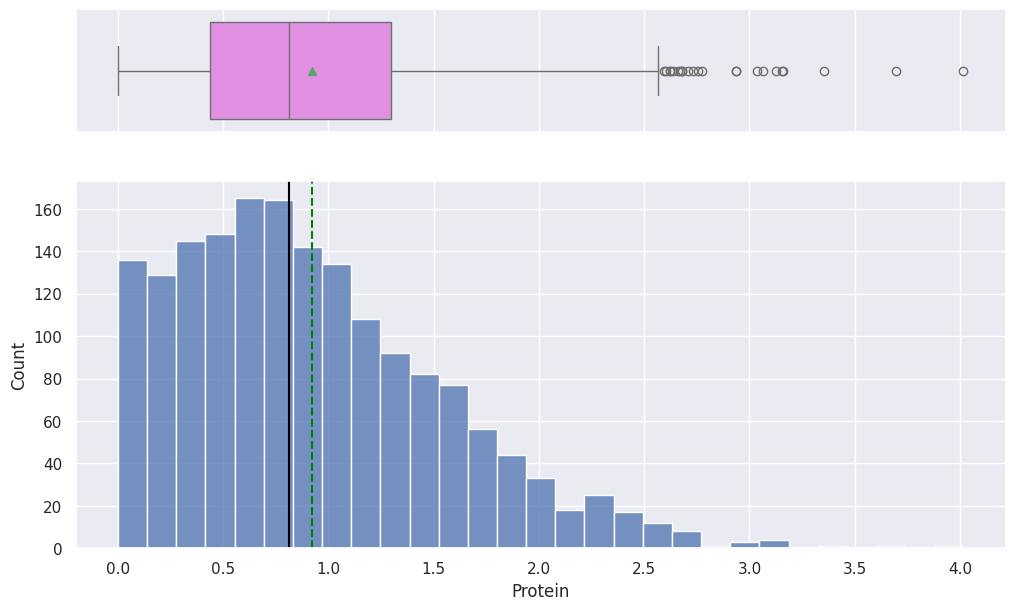

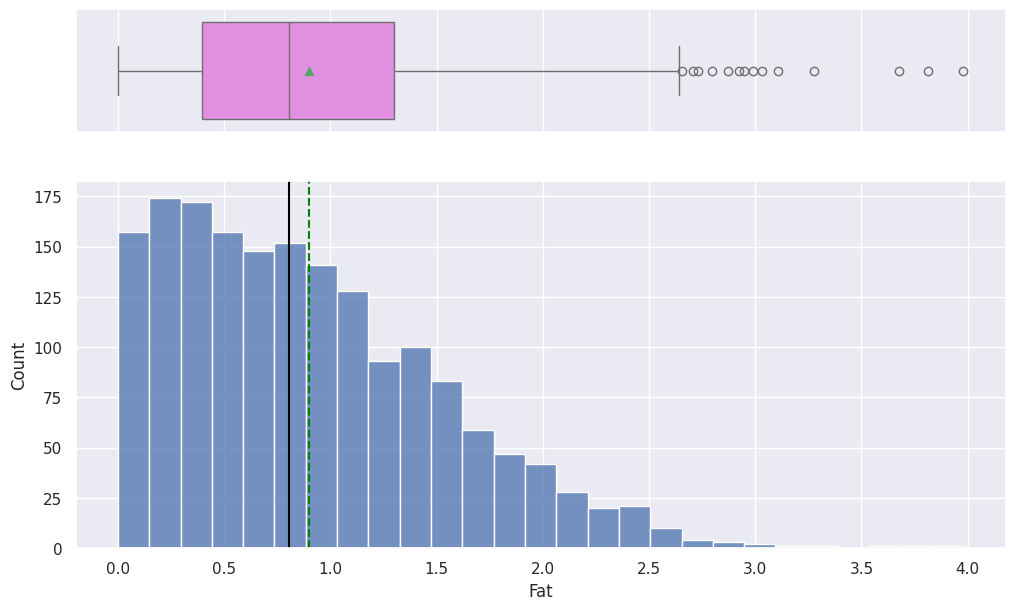

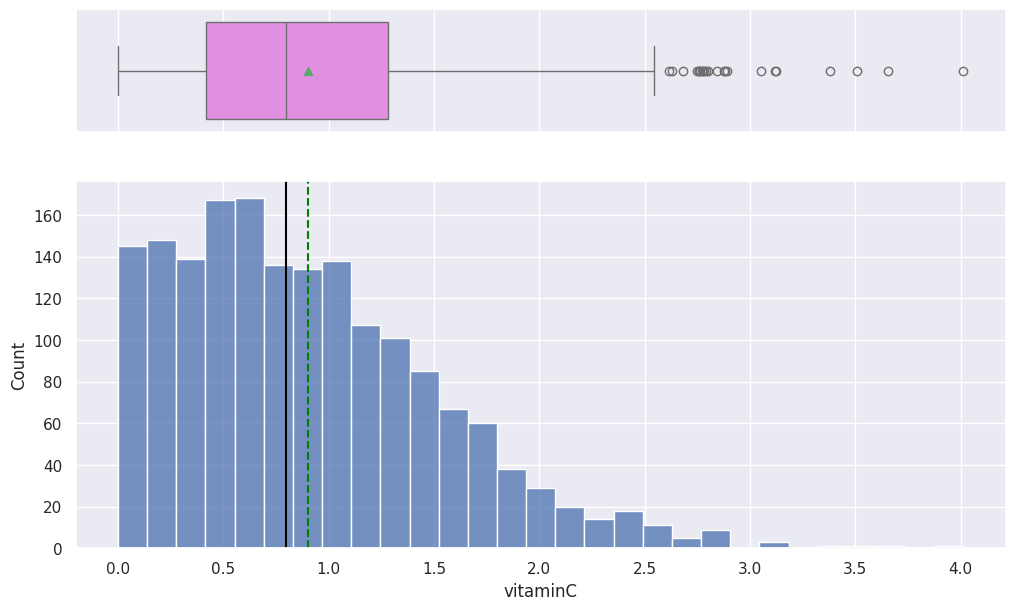

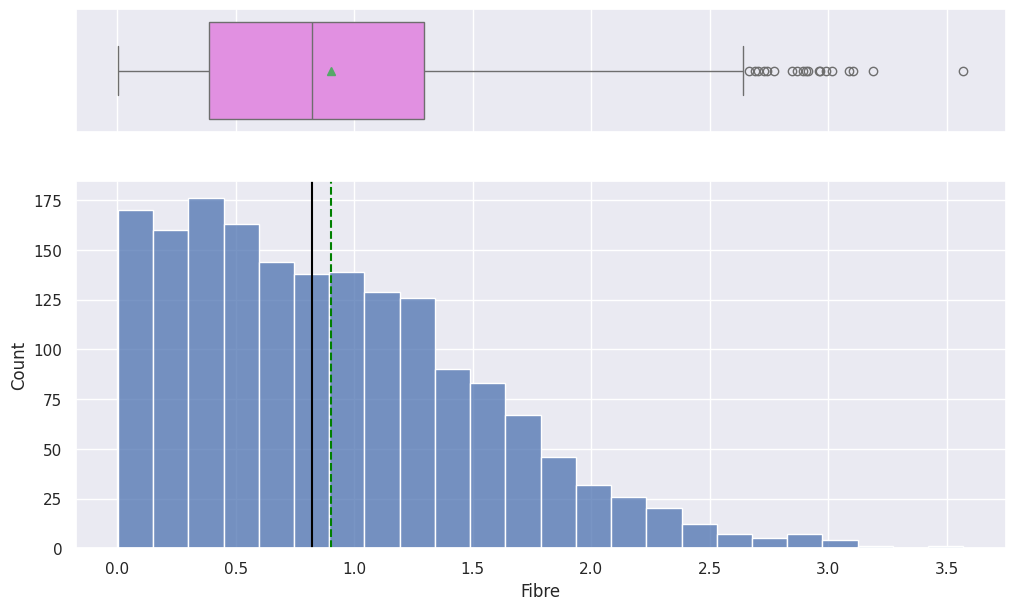

In [18]:
# selecting numerical columns
num_col = df.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    histogram_boxplot(df, item)

**Observations**

-

In [19]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

**Observations**

-

### Bivariate Analysis

**Let's check for correlations.**

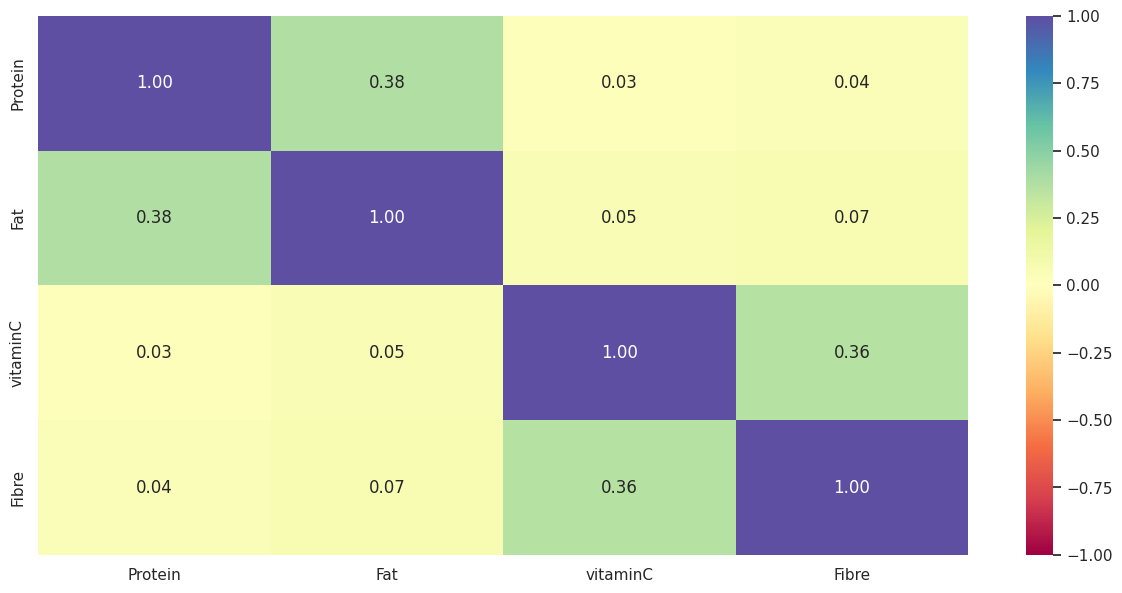

In [22]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations**

-

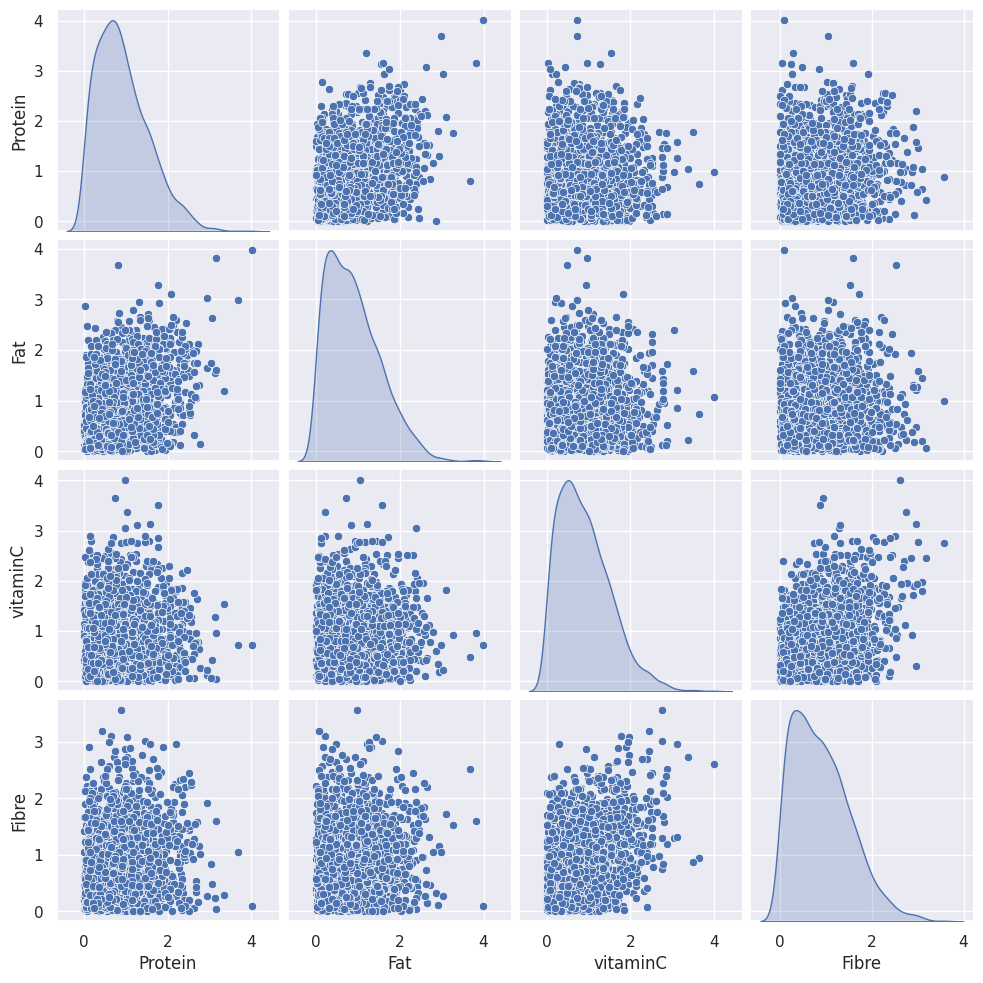

In [23]:
sns.pairplot(data=df[num_col], diag_kind="kde")
plt.show()

**Observations**

-

## Data Preprocessing

In [25]:
# variables used for clustering
num_col

['Protein', 'Fat', 'vitaminC', 'Fibre']

In [66]:
from scipy.stats import zscore

# Select the numerical columns for scaling
num_columns_to_scale = ['Protein', 'Fat', 'vitaminC', 'Fibre']
subset_for_zscore = df[num_columns_to_scale].copy()

# Apply the z-score scaling using scipy.stats.zscore
scaled_data_zscore_scipy = subset_for_zscore.apply(zscore)

print("First 5 rows of the z-score scaled DataFrame (using scipy.stats.zscore):")
print(scaled_data_zscore_scipy.head())

First 5 rows of the z-score scaled DataFrame (using scipy.stats.zscore):
    Protein       Fat  vitaminC     Fibre
0 -0.749825  0.426892  0.287212  1.279936
1  2.230835 -0.304578 -0.881972 -0.387079
2 -0.060478  0.451551  2.450659  1.729280
3 -0.330121 -0.508314 -1.008903 -0.848201
4 -1.259850 -0.560451 -1.255896 -0.548145


In [26]:
# scaling the dataset before clustering
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)

In [33]:
# creating a dataframe of the scaled columns
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

## Dimensionality Reduction and Visualization using t-SNE

### Reduction to 2 dimensions

In [34]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, n_jobs=-2, random_state=1)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions

In [41]:
tsne_2d_data.head()

,Feature 1,Feature 2
0,17.916521,8.178499
1,0.574163,-29.157230
2,19.424679,25.251778
3,-27.543350,-9.476574
4,-33.687527,2.324118


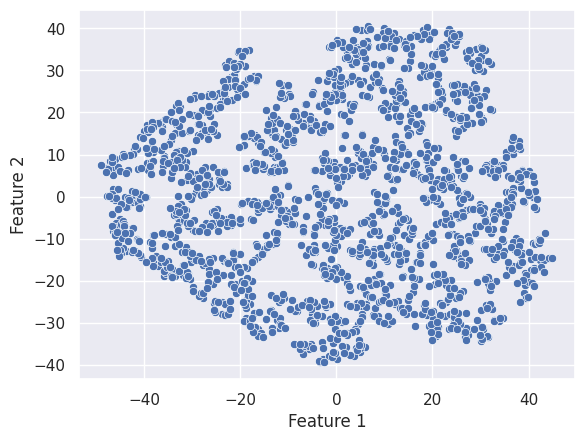

In [36]:
sns.scatterplot(data=tsne_2d_data, x="Feature 1", y="Feature 2");

- We can roughly see there are 3 clusters in the data.

- Let's try out different values of perplexity.

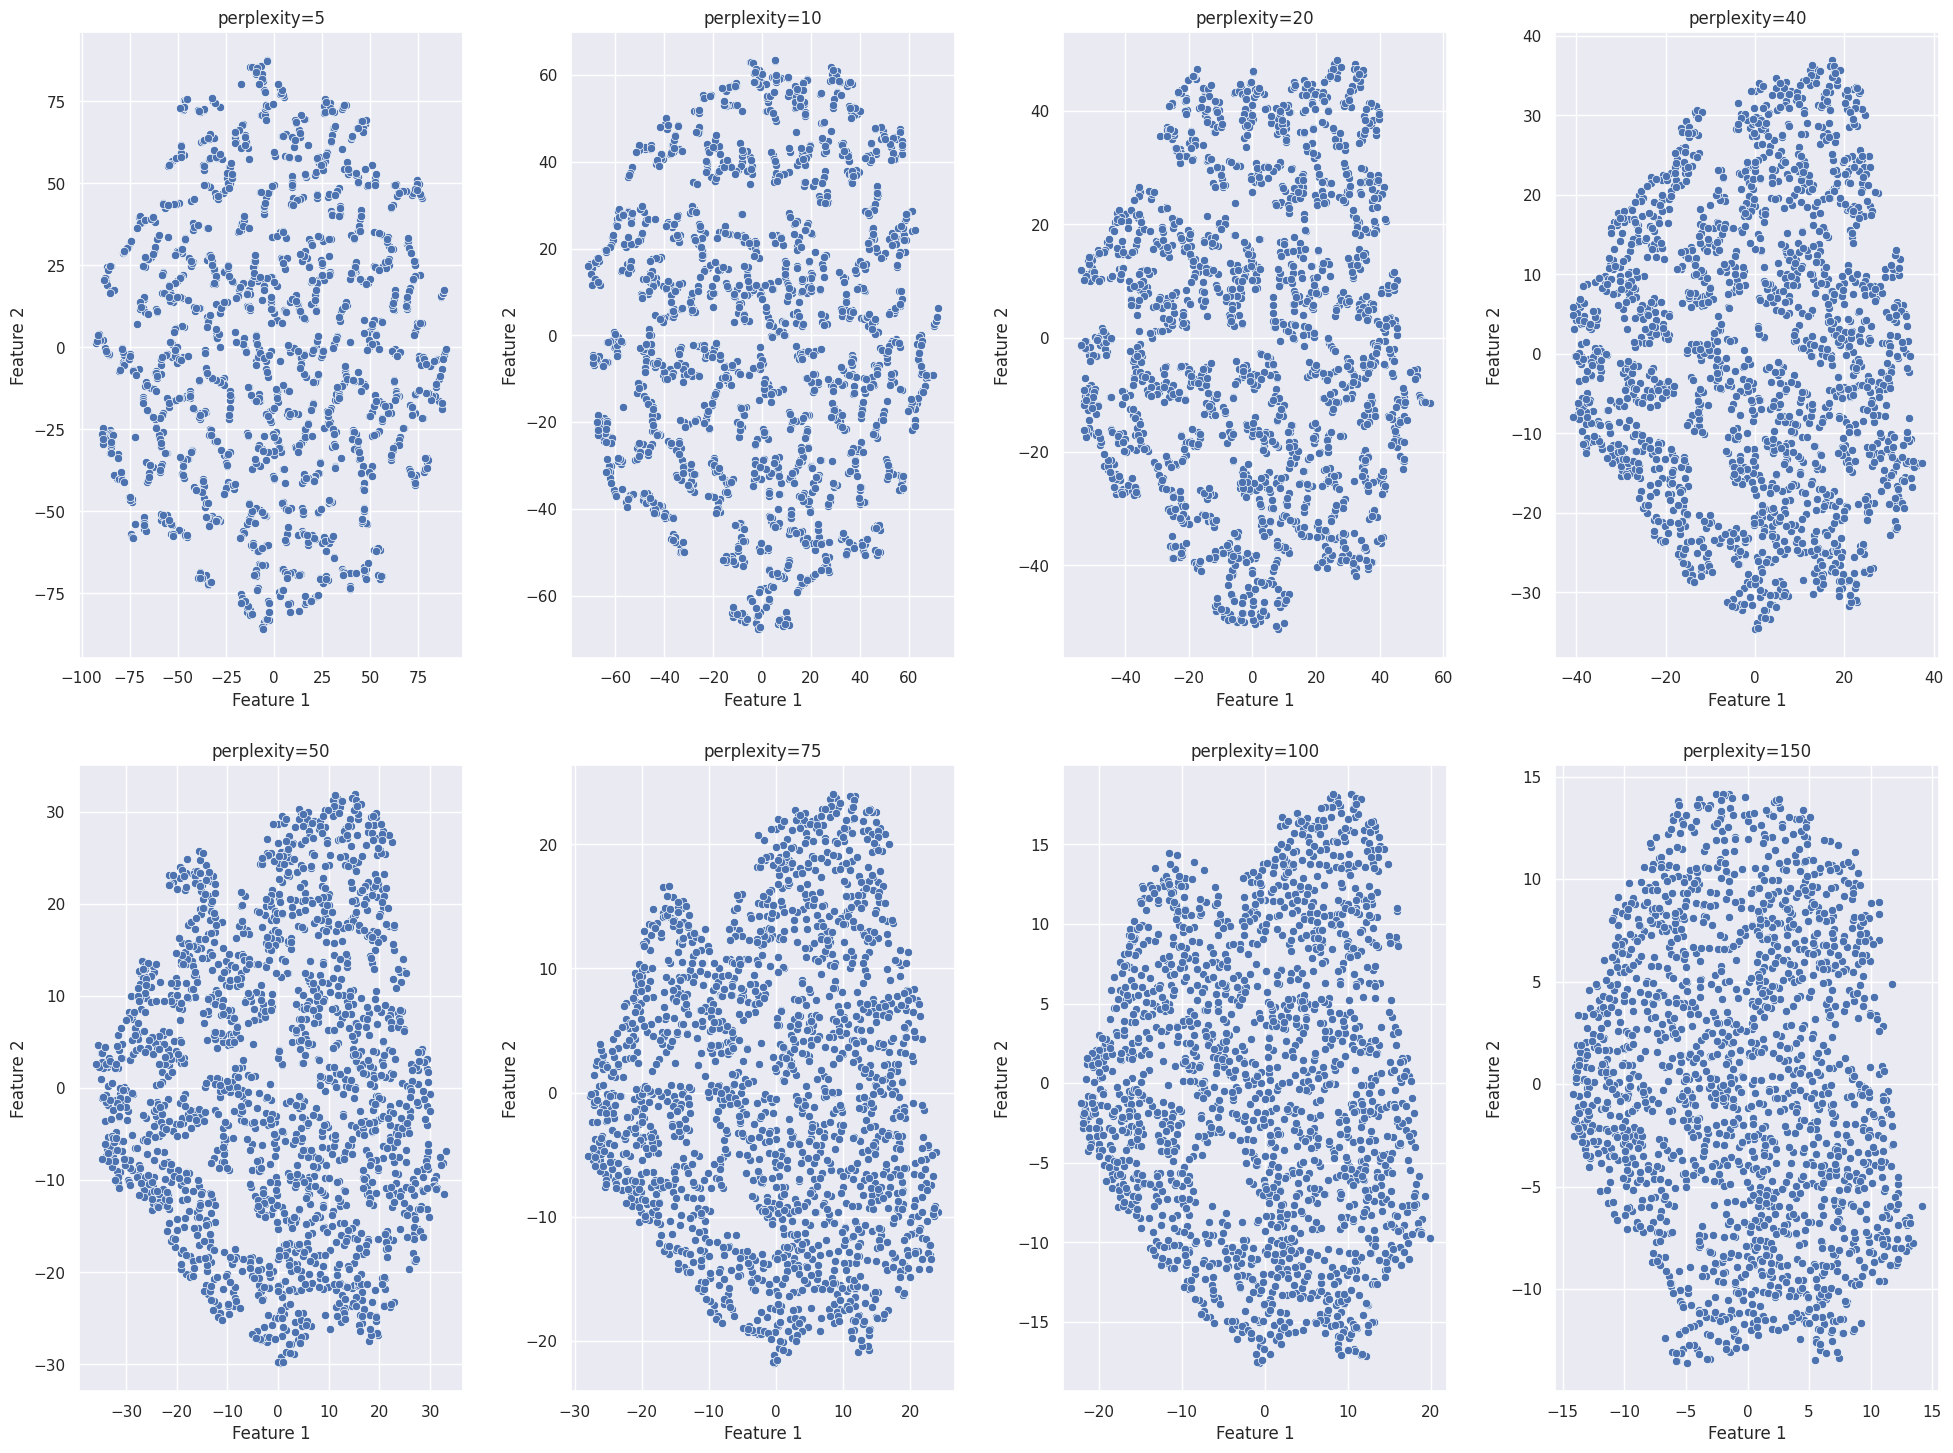

In [37]:
# Define the list of perplexity values to iterate over
perplexities = [5, 10, 20, 40, 50, 75, 100, 150]

plt.figure(figsize=(20, 15))

# Iterate over each perplexity value
for i in range(len(perplexities)):
    # Initiate TSNE with the current perplexity value
    tsne = TSNE(n_components=2, perplexity=perplexities[i], n_jobs=-2, random_state=1)    # n_jobs specifies the nunmber of cores to use for parallel computation; -2 means use all but 1 core
    X_red = tsne.fit_transform(subset_scaled_df)   # fit_transform() fits the TSNE model to the data and transforms it into the specified number of dimensions
    red_data_df = pd.DataFrame(data=X_red, columns=["Feature 1", "Feature 2"])    # creating a new dataframe with reduced dimensions

    # Adjust the subplot grid to 2x4
    plt.subplot(2, 4, i + 1)

    plt.title("perplexity=" + str(perplexities[i]))    # setting plot title
    sns.scatterplot(data=red_data_df, x="Feature 1", y="Feature 2")
    plt.tight_layout(pad=2)

plt.show()

-

In [39]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, perplexity=50, n_jobs=-2, random_state=1)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions
tsne_2d_data.head()

,Feature 1,Feature 2
0,17.916521,8.178499
1,0.574163,-29.157230
2,19.424679,25.251778
3,-27.543350,-9.476574
4,-33.687527,2.324118


### Reduction to 3 dimensions

- We'll go ahead with perplexity=50

In [42]:
# Initiating the TSNE object and setting output dimension to 3
# n_components=3 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one core for parallel computation, which speeds up the process
tsne = TSNE(n_components=3, perplexity=50, n_jobs=-2, random_state=1)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the TSNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_3d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2","Feature 3"])) # This DataFrame will have three columns corresponding to the three reduced dimensions

In [43]:
tsne_3d_data.head()

,Feature 1,Feature 2,Feature 3
0,2.233112,3.386561,-1.371289
1,-0.438803,-8.489023,3.437922
2,5.749194,6.754499,1.237870
3,-6.612422,-4.307290,-0.419724
4,-6.710244,1.005774,-2.596473


In [44]:
# plotting a 3D scatterplot
fig = px.scatter_3d(tsne_3d_data, x='Feature 1', y='Feature 2', z='Feature 3')
fig.show()

-

## Model Building

- We'll build a K-means Clustering model now.

In [45]:
k_means_df = subset_scaled_df.copy()

In [46]:
clusters = range(1, 15)
WCSS = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(subset_scaled_df)
    prediction = model.predict(k_means_df)

    wcss = model.inertia_


    WCSS.append(wcss)

    print("Number of Clusters:", k, "\twcss:", wcss)

Number of Clusters: 1 	wcss: 6984.000000000004
Number of Clusters: 2 	wcss: 5322.391090880907
Number of Clusters: 3 	wcss: 4173.559561975998
Number of Clusters: 4 	wcss: 3789.6842379785744
Number of Clusters: 5 	wcss: 3408.432788003226
Number of Clusters: 6 	wcss: 3073.19623716484
Number of Clusters: 7 	wcss: 2869.425860795365
Number of Clusters: 8 	wcss: 2696.497596168982
Number of Clusters: 9 	wcss: 2517.025227441324
Number of Clusters: 10 	wcss: 2375.5530438163214
Number of Clusters: 11 	wcss: 2275.0021785418967
Number of Clusters: 12 	wcss: 2189.2361638711163
Number of Clusters: 13 	wcss: 2091.32911341143
Number of Clusters: 14 	wcss: 2030.9616755684006


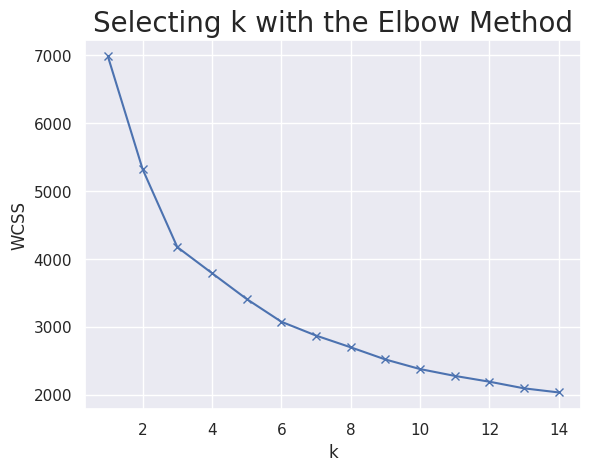

In [47]:
plt.plot(clusters,WCSS,"bx-")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

- Appropriate value for k seems to be 2 or 3.

Let's check the silhouette scores.

In [51]:
sil_score = []
cluster_list = range(2, 15)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, the silhouette score is 0.25241844825818016)
For n_clusters = 3, the silhouette score is 0.25457085564593496)
For n_clusters = 4, the silhouette score is 0.20209788371115694)
For n_clusters = 5, the silhouette score is 0.1956911786030402)
For n_clusters = 6, the silhouette score is 0.2071766029811893)
For n_clusters = 7, the silhouette score is 0.2045687931159596)
For n_clusters = 8, the silhouette score is 0.19596389627440364)
For n_clusters = 9, the silhouette score is 0.20117953507818484)
For n_clusters = 10, the silhouette score is 0.20493317387242002)
For n_clusters = 11, the silhouette score is 0.20677161338867206)
For n_clusters = 12, the silhouette score is 0.19776376721094044)
For n_clusters = 13, the silhouette score is 0.19929839529966792)
For n_clusters = 14, the silhouette score is 0.19183239882288844)


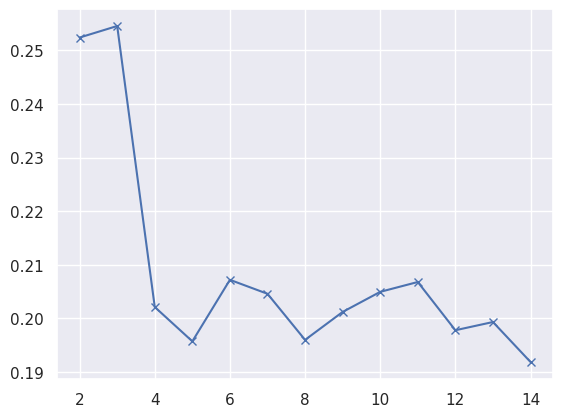

In [49]:
plt.plot(cluster_list, sil_score, "bx-")
plt.show()

**Observations**

- The silhouette coefficient for 3 clusters is the highest.

In [52]:
# let's take 4 as number of clusters
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=3, random_state=1)

In [67]:
print("Cluster Centroids:")
print(kmeans.cluster_centers_)

Cluster Centroids:
[[-0.41996865 -0.50421597 -0.48880149 -0.49756782]
 [-0.27581246 -0.186556    1.05710933  0.99677895]
 [ 1.02833386  1.09535632 -0.13053939 -0.05650916]]


In [53]:
# creating a copy of the original data
df1 = df.copy()

# adding kmeans cluster labels to the dataframes
k_means_df["K_means_segments"] = kmeans.labels_    # scaled
df1["K_means_segments"] = kmeans.labels_    # original
tsne_2d_data["K_means_segments"] = kmeans.labels_    # t-SNE 2D
tsne_3d_data["K_means_segments"] = kmeans.labels_    # t-SNE 3D

## Cluster Profiling

### Visualizing Final Clusters

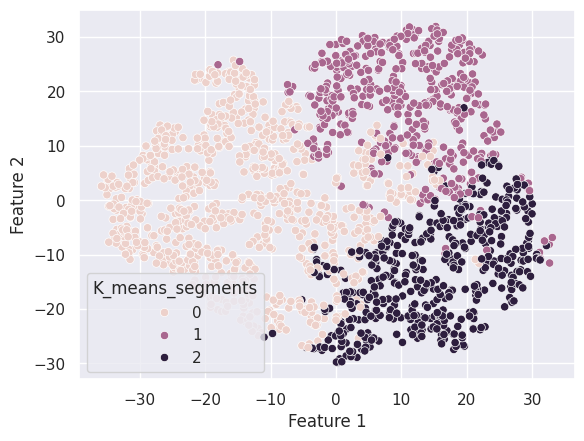

In [54]:
# visualizing the final cluster using t-SNE 2D
sns.scatterplot(data=tsne_2d_data, x='Feature 1', y='Feature 2', hue='K_means_segments');

In [55]:
# visualizing the final cluster using t-SNE 3D
# plotting a 3D scatterplot
fig = px.scatter_3d(tsne_3d_data, x='Feature 1', y='Feature 2', z='Feature 3',color='K_means_segments')
fig.show()

### Cluster Characteristics

In [56]:
cluster_profile = df1.select_dtypes(include=['number']).groupby("K_means_segments").mean()

In [59]:
cluster_profile["count_in_each_segments"] = (
    df1.select_dtypes(include=['number']).groupby("K_means_segments")["Protein"].count().values
)

In [60]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Protein,Fat,vitaminC,Fibre,count_in_each_segments
K_means_segments,,,,,
0,0.657214,0.580460,0.596482,0.588502,839
1,0.751050,0.781926,1.559416,1.527580,444
2,1.567525,1.592608,0.818198,0.865767,463


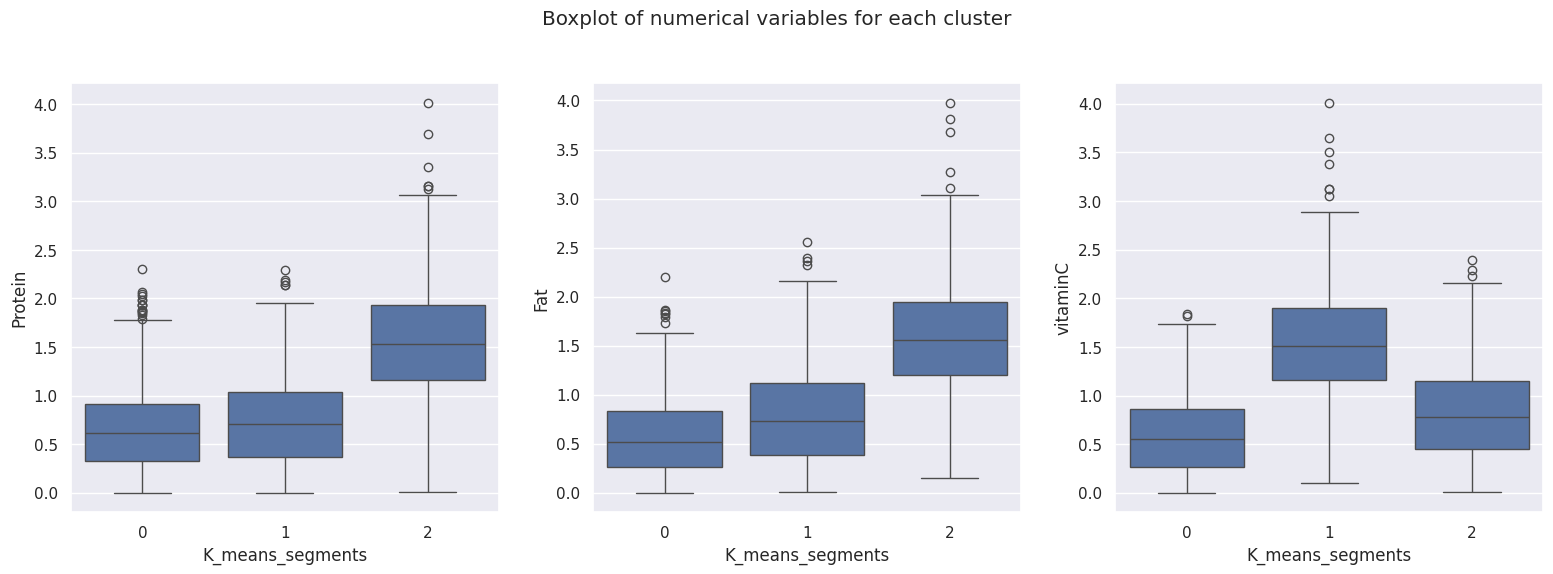

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Boxplot of numerical variables for each cluster")
counter = 0
for i in range(3):
    sns.boxplot(ax=axes[i], y=df1[num_col[counter]], x=df1["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

**Let's compare Cluster vs Brand**

**Observations**

- Adidas gives more discounts on their products, while Nike barely gives any.
- Nearly one-third of Nike products are premium in nature.

- **Cluster 0**:
    - This cluster contains more expensive premium products, with an average listing price of approximately 15500.
    - Almost no discount is given to products in this cluster.
    - The median rating of this cluster is around 4 suggesting that customers are very satisfied with 50% of the products in this cluster.
    - Products in these clusters have got lesser reviews, which can be because these products are very expensive and fewer people buy them.
   
- **Cluster 1**:
    - Listing price is low for products in this cluster, and the sale price is lower, as there are heavier discounts on these products.
    - 50% of the products have discounts between 30% to 40%.
    - More than 50% of products have a rating from 2.5 to 4.5 which indicates that customer satisfaction varies across products in this cluster.
    - On average, 50 reviews are given to products in this cluster.
    
- **Cluster 2**:
    - The listing price of products in this cluster is similar to those in Cluster 1, but the sale price is comparatively higher as there are almost no discounts.
    - On average, 38 reviews are given to products in this cluster.


- **Cluster 3**:
    - Listing and sale price of products in this cluster suggest that these are medium-range products.
    - Almost no discount is given to products in this cluster.
    - Products in this cluster have a low rating or no rating at all.

## Business Insights and Recommendations

**Recommendations**

- Cluster 0 consists of premium products, so focused marketing campaigns can be done to target customers with higher purchasing power.
- Cluster 0 products can also be made available in showrooms situated in premium locations because people generally tend to buy premium products from showrooms.
- Cluster 1 consists of products that are sold at higher discounts, so these might be the ones that are introduced in large quantity during festive sales (like Christmas, Black Friday, New Year, etc). This strategy can be continued with high inventory.
- Cluster 2 and 3 consists of products with comparatively low and medium prices with almost no discount, so general marketing campaigns can be done for these to target the general public.

<font size=5 color='blue'>Power Ahead!</font>
___